In [110]:
import pandas as pd
import numpy as np
import pickle
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
    
from xgboost import XGBClassifier

In [111]:
df = pd.read_pickle("../data/processed/bookings_ready_data.pkl")
df.shape

(100000, 31)

In [112]:
df.columns

Index(['booking_id', 'booking_date', 'booking_time', 'day_of_week',
       'is_weekend', 'hour_of_day', 'city', 'pickup_location', 'drop_location',
       'vehicle_type', 'ride_distance_km', 'estimated_ride_time_min',
       'actual_ride_time_min', 'traffic_level', 'weather_condition',
       'base_fare', 'surge_multiplier', 'booking_value', 'booking_status',
       'incomplete_ride_reason', 'customer_id', 'driver_id',
       'booking_datetime', 'customer_total_rides', 'is_loyal_customer',
       'is_cancelled', 'fare_per_km', 'fare_per_min', 'long_distance_flag',
       'City_Pair', 'rush_hour_flag'],
      dtype='str')

In [113]:
drop_cols = ["booking_id","booking_date","booking_time","pickup_location","drop_location","customer_id",
             "driver_id","booking_datetime","day_of_week","City_Pair","is_weekend","rush_hour_flag","city",
             "long_distance_flag","is_loyal_customer","vehicle_type","is_cancelled",
             "fare_per_km","fare_per_min","actual_ride_time_min"
             ]
df = df.drop(columns=drop_cols, errors="ignore")

In [114]:
# Target columns (based on your use cases)
target_outcome = "booking_status"        # Completed / Cancelled / Incomplete


# Identify column types
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = df.select_dtypes(exclude=["object", "string"]).columns.tolist()

# Remove targets from feature lists
cat_cols = [c for c in cat_cols if c not in [target_outcome]]


print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['traffic_level', 'weather_condition', 'incomplete_ride_reason']
Numerical: ['hour_of_day', 'ride_distance_km', 'estimated_ride_time_min', 'base_fare', 'surge_multiplier', 'booking_value', 'customer_total_rides']


In [115]:
TARGET_CLASS = "booking_status"
X = df.drop(columns=[TARGET_CLASS])
y= df[TARGET_CLASS]


In [116]:
# Encode target 

label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y)

# Save label encoder for deployment
with open("../models/label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder,f)

print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))

{'Cancelled': np.int64(0), 'Completed': np.int64(1), 'Incomplete': np.int64(2)}


In [117]:
# Build Preprocessing Pipeline for encoding and scaling
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_class_encoded   # to balance classes 
)

In [119]:
y_class_encoded

array([0, 1, 0, ..., 1, 1, 1], shape=(100000,))

In [120]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weight_dict = {
    0: 2.0,   # risky rides (keep high)
    1: 1.0,   # completed rides
    2: 2.5    # rare class
}

sample_weights = np.array([class_weight_dict[y] for y in y_train])


In [121]:


xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=classes,
    eval_metric="mlogloss",
    tree_method="hist",   # ⚡ fast training
    n_jobs=-1,
    random_state=42,
    max_delta_step=1 
)

In [122]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb)
])

In [123]:
param_grid = {
    "model__n_estimators": [200],
    "model__max_depth": [6,8],
    "model__learning_rate": [0.02, 0.03, 0.05],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__reg_alpha": [0,0.3, 0.7],   # L1 Regularization
    "model__reg_lambda": [1, 2,3],  # L2 Regularization
    "model__min_child_weight": [ 3, 5, 7],
    "model__gamma": [0.1, 0.3, 0.5]    
}

In [124]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=30,          # try 30 random combos
    cv=cv,
    scoring="f1_macro",
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(
    X_train, y_train,
    model__sample_weight=sample_weights
)

best_model = search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [125]:
best_model = search.best_estimator_
print("Best Params:", search.best_params_)

Best Params: {'model__subsample': 0.8, 'model__reg_lambda': 3, 'model__reg_alpha': 0.3, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 6, 'model__learning_rate': 0.02, 'model__gamma': 0.3, 'model__colsample_bytree': 0.8}


In [126]:
y_pred_train = best_model.predict(X_train)

print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("F1 Score:", f1_score(y_train, y_pred_train, average="weighted"))
print(classification_report(y_train, y_pred_train))


Accuracy: 0.7509875
F1 Score: 0.7498258067857678
              precision    recall  f1-score   support

           0       0.46      0.45      0.46     18627
           1       0.81      0.82      0.82     54677
           2       1.00      1.00      1.00      6696

    accuracy                           0.75     80000
   macro avg       0.76      0.76      0.76     80000
weighted avg       0.75      0.75      0.75     80000



In [127]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print(classification_report(y_test, y_pred))

Accuracy: 0.74455
F1 Score: 0.7440846065967653
              precision    recall  f1-score   support

           0       0.45      0.45      0.45      4657
           1       0.81      0.81      0.81     13669
           2       1.00      1.00      1.00      1674

    accuracy                           0.74     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.74      0.74      0.74     20000



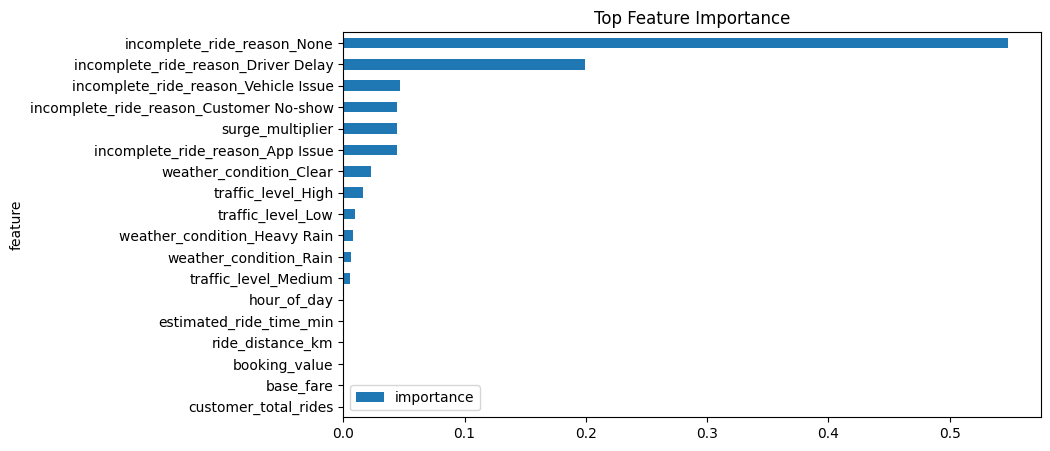

In [128]:
import matplotlib.pyplot as plt

# Get feature names after encoding
ohe_features = best_model.named_steps["prep"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(cat_cols)

all_features = num_cols + list(ohe_features)

importances = best_model.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(20).plot(kind="barh", x="feature", y="importance", figsize=(9,5))
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.show()

In [129]:
import joblib
joblib.dump(best_model, "ride_outcome_xgb.pkl")

['ride_outcome_xgb.pkl']